## Exercise 3

- Use the MinMaxScaler to normalize the training and testing set
betwee 0 and 1. Name the normalized outputs norm_train and
norm_test.
- Write a function that separates the data into an input array (X)
which has all the datapoint at times t-i's, and an output array
which contains the data at timepoint t.
- Improve the results above by trying the following: increase the number of
epochs, increase the look_back value and modify the Architecture

#### Import Dataset

This dataset is about $CO_2$ production in parts per million (ppm) from the volcano Mauna Loa between 1965-1980 by month.

In [9]:
df=pd.read_csv('Appendix 4 - co2-ppm-mauna-loa-19651980.csv',usecols=[1], engine='python', skipfooter=3)

#### Visualization

As observed in the time series, CO2 concentration exhibits a clear upward trend over time, indicating a steady increase in atmospheric CO2 levels. In addition, the data shows a strong cyclical pattern, with regular fluctuations that repeat approximately every 12 time steps ( months), suggesting a seasonal component.

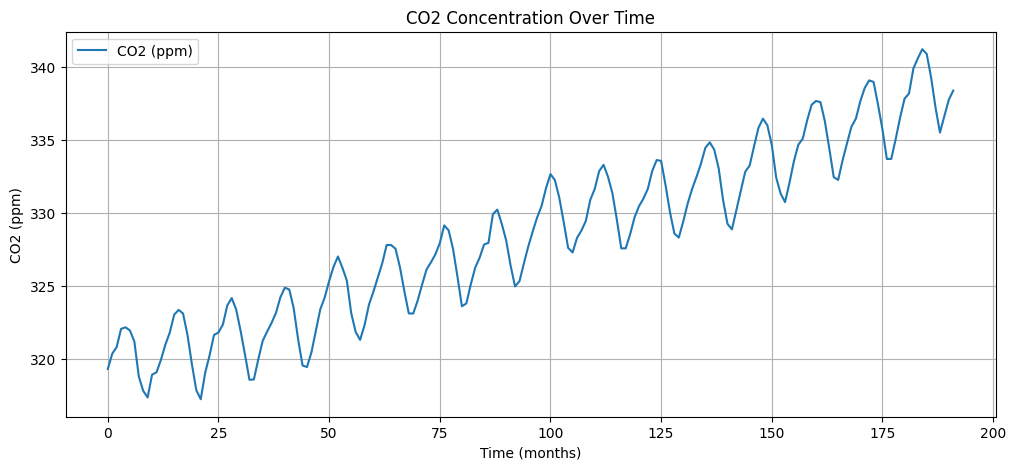

In [11]:

plt.figure(figsize=(12,5))
plt.plot(df['CO2 (ppm) mauna loa, 1965-1980'], label='CO2 (ppm)')

plt.title('CO2 Concentration Over Time')
plt.xlabel('Time (months)')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid()

plt.show()

#### Making train-test split

The dataset was first transformed into a numerical array by extracting the CO2 concentration values from the DataFrame. Then, the data was divided into two subsets: a training set and a testing set. The split was performed using 67% of the observations for training and the remaining 33% for testing, preserving the original temporal order of the series. This approach ensures that the model is trained on past values and evaluated on future observations, which is appropriate for time series forecasting tasks. 

In this case, the training set contains 128 observations, while the test set contains 64 observations.

In [13]:
data = df['CO2 (ppm) mauna loa, 1965-1980'].values

train_size = int(len(data) * 0.67)

train = data[:train_size]
test = data[train_size:]

print('Train set size:', len(train))
print('Test set size:', len(test))

Train set size: 128
Test set size: 64


Remember that LSTMs are sensitive to the scale of the input data, specifically when the sigmoid (default) or tanh activation functions are used. It is recommended to rescale (normalize) the data to the range of [0, 1].(Mañas Mañas, 2019)

#### MinMax Scaler

The training and testing sets were normalized using the MinMaxScaler, which scales the data to a range between 0 and 1. The scaler was fitted using only the training data and then applied to both the training and testing sets. This ensures that the model does not incorporate information from the test set during training, preventing data leakage and maintaining the integrity of the evaluation process.

In [15]:
scaler = MinMaxScaler(feature_range=(0, 1))
norm_train = scaler.fit_transform(train.reshape(-1, 1))
norm_test = scaler.transform(test.reshape(-1, 1))

### Creation of Input-Output Sequences

In this step, the normalized time series was transformed into a supervised learning format by creating input-output sequences. A custom function was defined to generate pairs of data, where each input (X) consists of a sequence of past observations over a fixed window of 12 time steps, and the corresponding output (y) represents the value at the next time step. The choice of 12 time steps is based on the observed behavior of the series, which shows a clear seasonal pattern that repeats approximately every 12 periods, consistent with monthly data exhibiting annual cycles.

The function was then applied to both the training and testing datasets, producing the arrays `train_X`, `train_y`, `test_X`, and `test_y`. This transformation is essential for training sequence-based models such as RNNs and LSTMs, as it converts the original time series into a structure suitable for supervised learning while preserving both trend and seasonal dynamics.

In [33]:
def create_dataset(data, look_back=12):
    X, y = [], []
    
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back])
        
    return np.array(X), np.array(y)


look_back = 12

train_X, train_y = create_dataset(norm_train, look_back)
test_X, test_y = create_dataset(norm_test, look_back)

### Reshape LSTM


After creating the input-output sequences, the input arrays were reshaped to match the format required by LSTM models. Specifically, the data was transformed into a three-dimensional structure with the shape (samples, timesteps, features). In this case, each sample corresponds to one sequence of observations, the number of timesteps is 12 (representing the past 12 months), and the number of features is 1, since only the CO2 variable is being used.

This reshaping step is necessary because LSTM networks expect input data in this specific format in order to properly process sequential information. Without this transformation, the model would not be able to interpret the temporal structure of the data, as it would treat the inputs as simple flat arrays instead of ordered sequences.

In [34]:
train_X = train_X.reshape(train_X.shape[0], train_X.shape[1], 1)
test_X = test_X.reshape(test_X.shape[0], test_X.shape[1], 1)

#### Applying Simple LSMT

The baseline LSTM model with 10 units and 10 epochs produces overly smooth predictions that fail to capture the variability of the time series. While the model is able to identify a general upward trend, it does not reproduce the seasonal fluctuations present in the data. This indicates that the model is underfitting, as it lacks sufficient capacity and training to learn the underlying temporal patterns.

c:\Users\carlo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


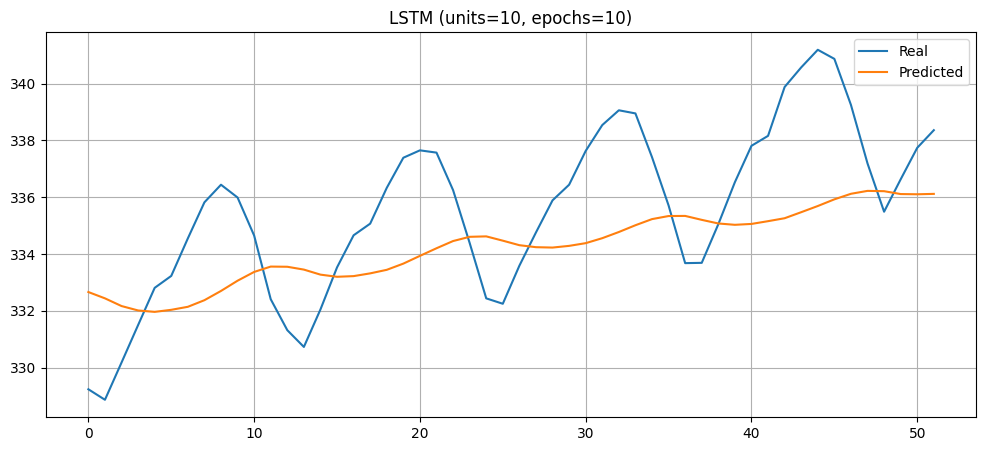

In [22]:
run_lstm_model(train_X, train_y, test_X, test_y, scaler, units=10, epochs=10)

#### Model 2: LSTM ( Units:100, Epoch:100)

The LSTM model with 100 units and 100 epochs shows a significant improvement compared to the baseline configuration. The model is now able to capture both the upward trend and the seasonal fluctuations present in the data, producing predictions that closely follow the overall shape of the time series. This indicates that the model has gained sufficient capacity to learn the underlying temporal patterns.

However, the predictions still tend to slightly underestimate peak values and do not fully capture the amplitude of extreme fluctuations. While the model performs well overall, these differences suggest that there is still room for refinement, either through additional tuning or adjustments to the model configuration.

c:\Users\carlo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


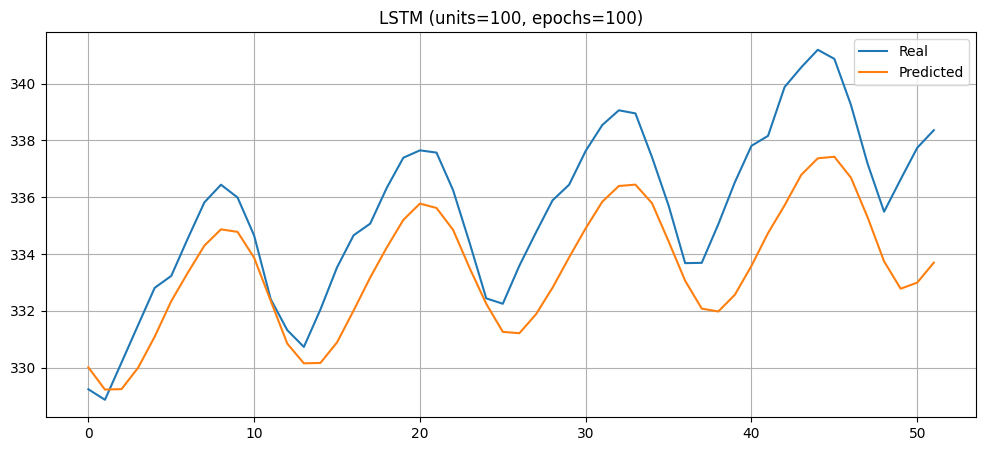

In [24]:
run_lstm_model(train_X, train_y, test_X, test_y, scaler, units=100, epochs=100)

#### look_back=24

In [30]:
look_back = 24
train_X, train_y = create_dataset(norm_train, look_back)
test_X, test_y = create_dataset(norm_test, look_back)

train_X = train_X.reshape(train_X.shape[0], train_X.shape[1], 1)
test_X = test_X.reshape(test_X.shape[0], test_X.shape[1], 1)

Increasing the look_back parameter from 12 to 24 did not improve the model performance. Although a larger window provides more historical context, it also reduces the number of training samples and may introduce unnecessary complexity. In this case, the model produced less accurate predictions and showed a greater deviation from the actual values. This suggests that a look_back value of 12 is more appropriate, as it effectively captures the seasonal pattern present in the data without overcomplicating the learning process.

c:\Users\carlo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


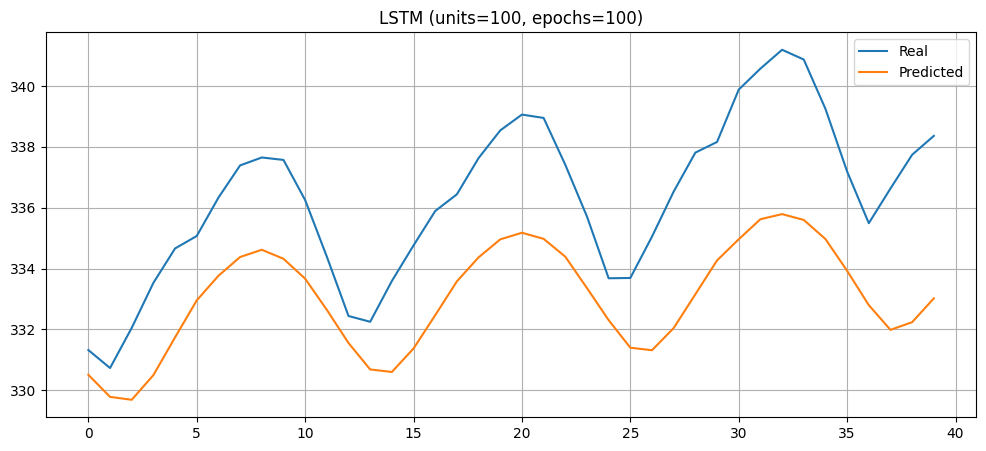

In [31]:
run_lstm_model(train_X, train_y, test_X, test_y, scaler, units=100, epochs=100)

### Modified LSTM Architecture

In order to improve the model’s performance, the architecture of the LSTM network was modified by introducing an additional recurrent layer. Specifically, a stacked LSTM structure was implemented, where the first layer returns sequences that are then processed by a second LSTM layer. This modification allows the model to capture more complex temporal dependencies and hierarchical patterns in the data compared to the single-layer architecture used previously.

The implementation of this modified architecture was carried out using a custom function, whose full structure and code can be found in Appendix C.

#### Model

The deep LSTM model shows a slight improvement in capturing the overall shape of the time series compared to the single-layer model. It is able to represent both the trend and seasonal behavior with a reasonable level of accuracy. However, the improvements are minimal, as the model still underestimates peak values and does not significantly outperform the previous configuration.

This suggests that increasing the architectural complexity does not lead to substantial gains in this case. The simpler LSTM model was already capable of capturing the main patterns in the data, and further complexity results in diminishing returns rather than meaningful improvements.

c:\Users\carlo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


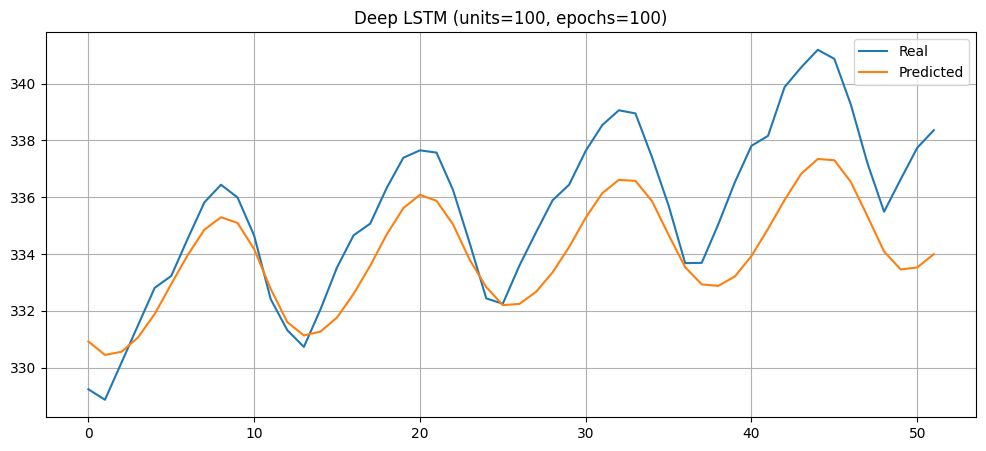

In [35]:
run_lstm_deep(train_X, train_y, test_X, test_y, scaler, units=100, epochs=100)

In [21]:
def run_lstm_model(train_X, train_y, test_X, test_y, scaler, units=50, epochs=50):
    
    

    model = Sequential()
    model.add(LSTM(units=units, input_shape=(train_X.shape[1],1)))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse')
    

    model.fit(train_X, train_y, epochs=epochs, verbose=0)
    
  
    predictions = model.predict(test_X, verbose=0)
    
  
    predictions_real = scaler.inverse_transform(predictions)
    test_y_real = scaler.inverse_transform(test_y.reshape(-1,1))
    

    plt.figure(figsize=(12,5))
    plt.plot(test_y_real, label='Real')
    plt.plot(predictions_real, label='Predicted')
    plt.title(f'LSTM (units={units}, epochs={epochs})')
    plt.legend()
    plt.grid()
    plt.show()

In [32]:
def run_lstm_deep(train_X, train_y, test_X, test_y, scaler, units=80, epochs=100):
    
    from keras.models import Sequential
    from keras.layers import LSTM, Dense
    import matplotlib.pyplot as plt
    
    model = Sequential()
    
 
    model.add(LSTM(units, return_sequences=True, input_shape=(train_X.shape[1],1)))

    model.add(LSTM(50))

    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse')

    model.fit(train_X, train_y, epochs=epochs, verbose=0)

    predictions = model.predict(test_X, verbose=0)
    

    predictions_real = scaler.inverse_transform(predictions)
    test_y_real = scaler.inverse_transform(test_y.reshape(-1,1))
    
    plt.figure(figsize=(12,5))
    plt.plot(test_y_real, label='Real')
    plt.plot(predictions_real, label='Predicted')
    plt.title(f'Deep LSTM (units={units}, epochs={epochs})')
    plt.legend()
    plt.grid()
    plt.show()